In [ ]:
!pip install -q kagglehub


 SETUP
PyTorch 2.11.0+cu130 | device: cuda | epochs: 20 | seeds: [0, 1, 2] | lr: 0.001
Using Colab cache for faster access to the 'garbage-classification' dataset.
Downloaded dataset to: /kaggle/input/garbage-classification
Dataset source: Kaggle - asdasdasasdas/garbage-classification

 1. DATASET INSPECTION
Folder: /kaggle/input/garbage-classification/Garbage classification/Garbage classification
2527 images | 6 classes | imbalance ratio 4.3 | modes {'RGB': 2527} | unreadable files 0

  class            images   share   size min / median / max
  --------------------------------------------------------------
  cardboard           403   15.9%   512x384 / 512x384 / 512x384
  glass               501   19.8%   512x384 / 512x384 / 512x384
  metal               410   16.2%   512x384 / 512x384 / 512x384
  paper               594   23.5%   512x384 / 512x384 / 512x384
  plastic             482   19.1%   512x384 / 512x384 / 512x384
  trash               137    5.4%   512x384 / 512x384 / 512x384

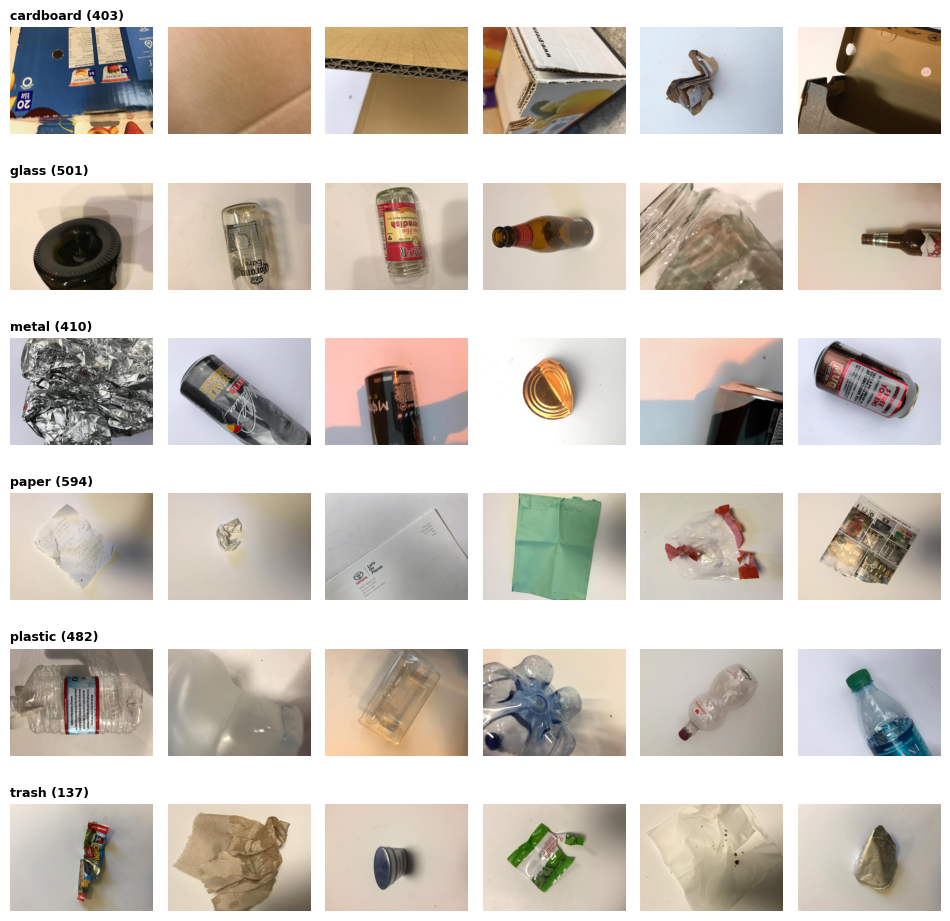


--- Class distribution ------------------------------------------------------


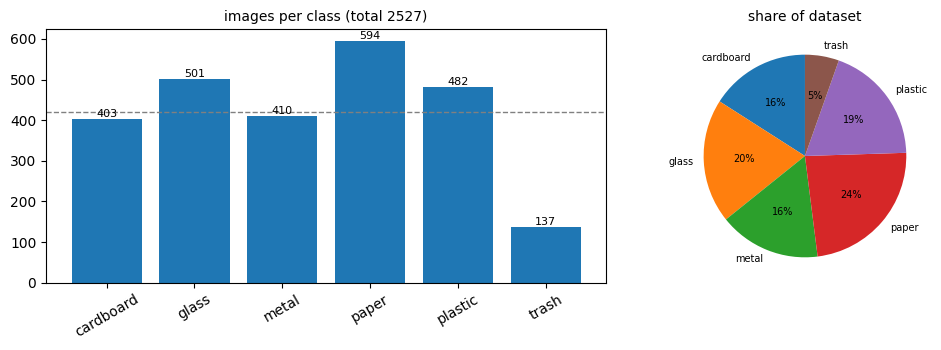


--- What the networks see: original vs 32x32 --------------------------------


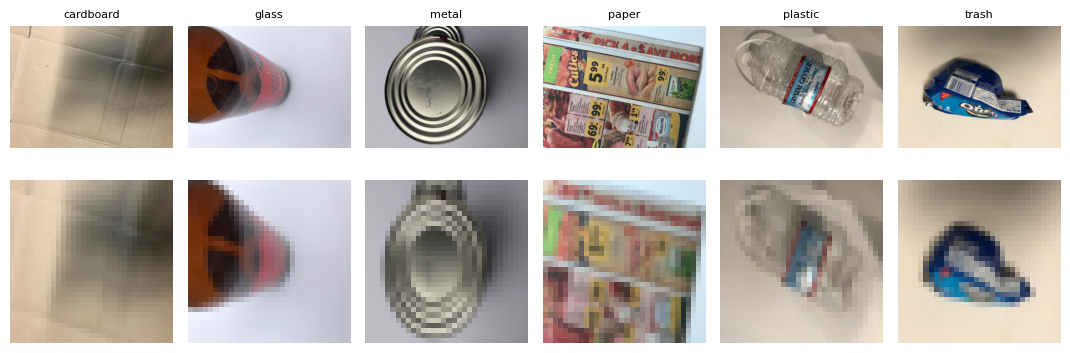


 2. TRAIN / TEST SPLIT
Balanced: each class capped at 274 images (2x the smallest class)
Dataset: /kaggle/input/garbage-classification/Garbage classification/Garbage classification
1507 images | 6 classes | split: random 80/20 split by image

  class                 total  train   test
  -----------------------------------------
  cardboard               274    223     51
  glass                   274    212     62
  metal                   274    206     68
  paper                   274    232     42
  plastic                 274    217     57
  trash                   137    116     21


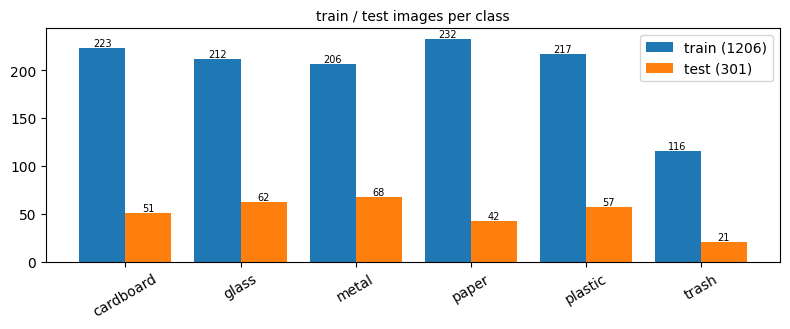


--- Parameter counts --------------------------------------------------------
  LeNet-5               61,666
  AlexNet-lite         542,918
  VGG-16-lite        1,023,254
  PlacesNet-lite       635,181
  ResNet-18-lite       700,950

 3. TRAINING  (seed 0)

  [LeNet-5]
  LeNet-5         epoch  1/20: test accuracy 0.385
  LeNet-5         epoch  2/20: test accuracy 0.402
  LeNet-5         epoch  3/20: test accuracy 0.389
  LeNet-5         epoch  4/20: test accuracy 0.395
  LeNet-5         epoch  5/20: test accuracy 0.409
  LeNet-5         epoch  6/20: test accuracy 0.432
  LeNet-5         epoch  7/20: test accuracy 0.439
  LeNet-5         epoch  8/20: test accuracy 0.468
  LeNet-5         epoch  9/20: test accuracy 0.472
  LeNet-5         epoch 10/20: test accuracy 0.505
  LeNet-5         epoch 11/20: test accuracy 0.472
  LeNet-5         epoch 12/20: test accuracy 0.502
  LeNet-5         epoch 13/20: test accuracy 0.482
  LeNet-5         epoch 14/20: test accuracy 0.492
  LeNet-5      

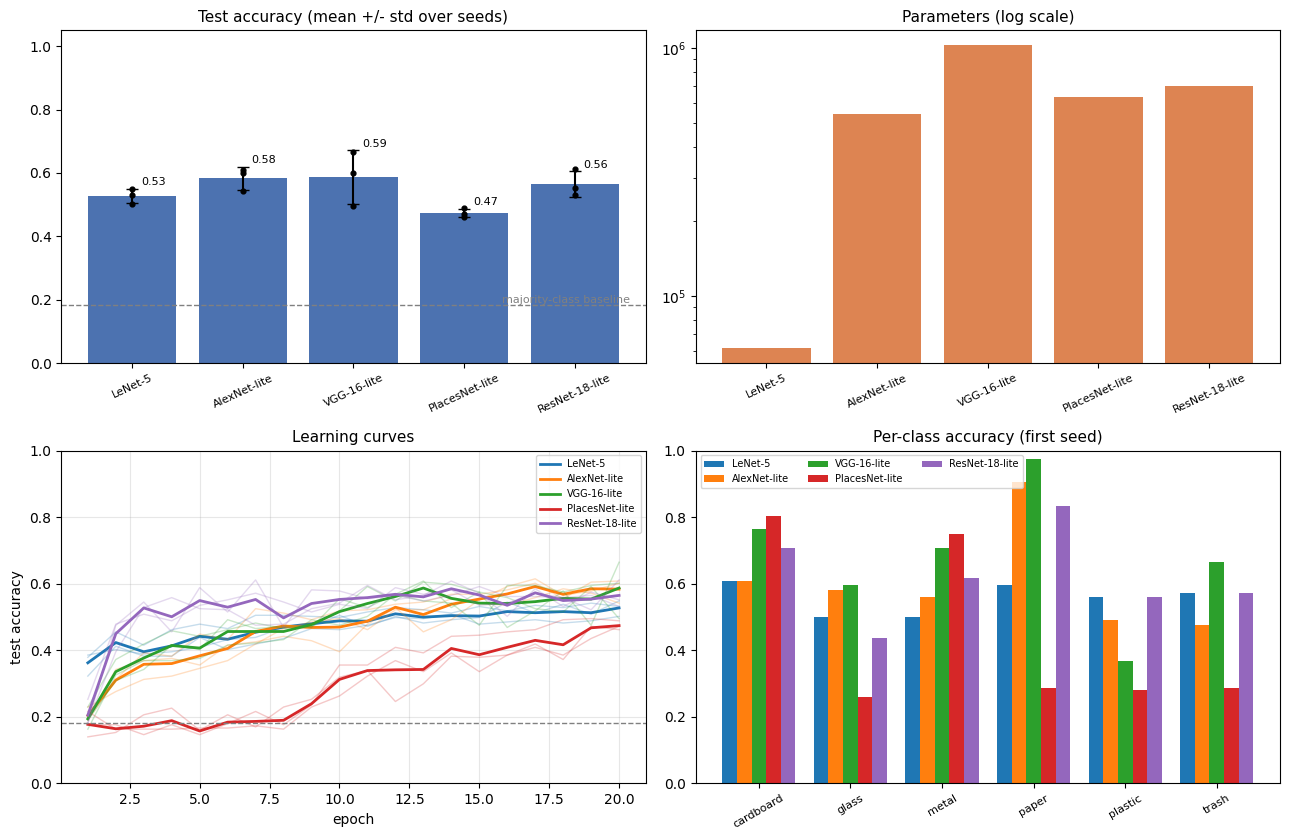


 5. CONFUSION MATRICES  (first seed)
  LeNet-5         plastic -> glass (13); glass -> plastic (11); metal -> paper (9)
  AlexNet-lite    metal -> paper (12); plastic -> glass (11); metal -> glass (11)
  VGG-16-lite     glass -> metal (18); plastic -> glass (15); plastic -> metal (14)
  PlacesNet-lite  glass -> metal (25); paper -> metal (23); plastic -> glass (21)
  ResNet-18-lite  plastic -> metal (12); glass -> metal (12); glass -> plastic (11)



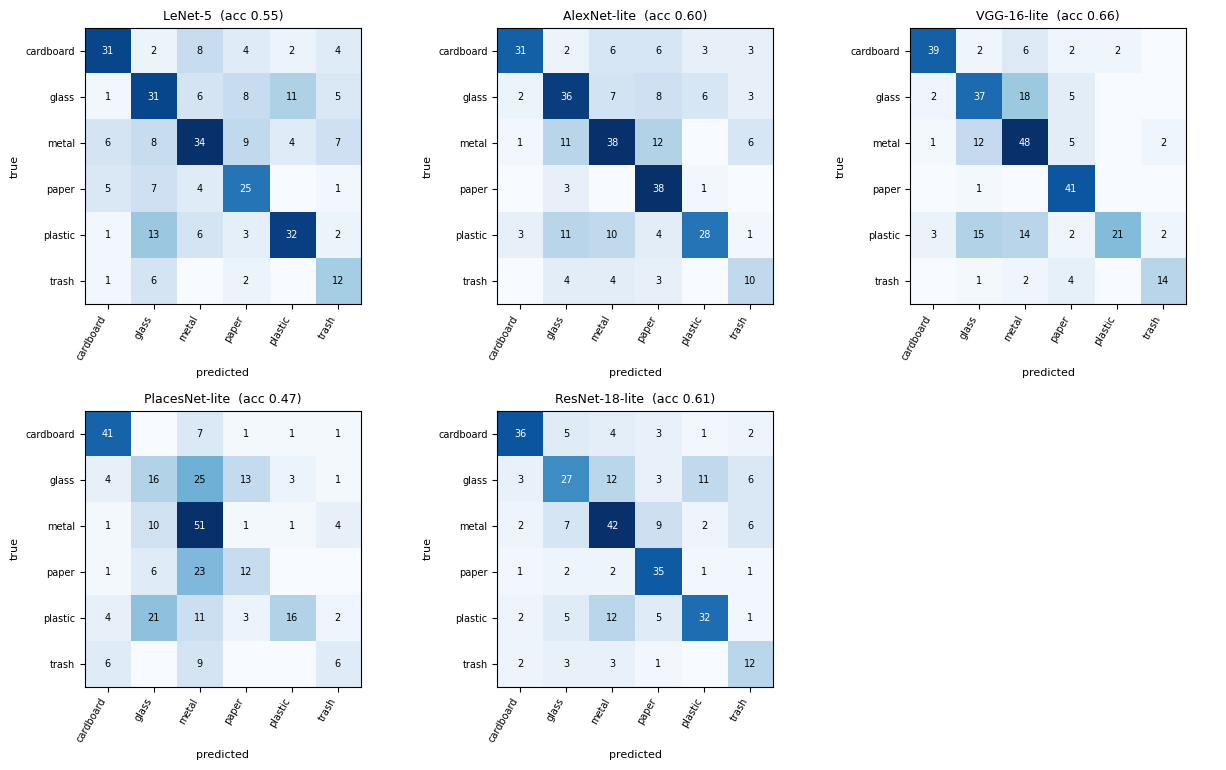


Saved: comparison.png and models/ (trained networks, seed 0).  Next: python mini_project.py gui


In [ ]:
#!/usr/bin/env python3
"""
Mini Project - Compare the five CNN architectures on your own dataset
=====================================================================
LeNet-5, AlexNet-lite, VGG-16-lite, PlacesNet-lite and ResNet-18-lite are trained
on the SAME training split, for the SAME number of epochs, with the SAME training
code, and tested on the SAME held-out split.

Requirements:  pip install torch torchvision matplotlib pillow kagglehub

Usage
-----
    python mini_project.py train --kaggle asdasdasasdas/garbage-classification
    python mini_project.py train --data <folder> --epochs 20 --seeds 0 1
    python mini_project.py train --group-split         # patient-level split
    python mini_project.py train --balance             # cap classes at 2x the smallest
    python mini_project.py train --hide-epochs         # hide the per-epoch lines
    python mini_project.py train --save                # ALSO write csv/json and all other png files
    python mini_project.py inspect --data my_dataset   # look at the dataset only
    python mini_project.py gui                         # needs `train` first (uses models/)
    python mini_project.py make-demo                   # tiny synthetic dataset

By default NOTHING is written to disk: all graphs and tables appear in the output only.
Use --save if you want files (and trained models for the `gui` command).
"""
import argparse
import csv
import json
import math
import os
import sys
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.datasets import ImageFolder

device = "cuda" if torch.cuda.is_available() else "cpu"

IMG = 32
tf = T.Compose([T.Resize((IMG, IMG)), T.ToTensor(), T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

SAVE = False      # default: show only, write nothing
SHOW_EPOCHS = True  # print test accuracy after every epoch (as in the lab)


# =============================================================================
# 0. Output formatting helpers
# =============================================================================
def section(title, char="="):
    print("\n" + char * 78)
    print(f" {title}")
    print(char * 78)


def sub(title):
    print(f"\n--- {title} " + "-" * max(0, 72 - len(title)))


# =============================================================================
# 1. Helpers
# =============================================================================
def count_params(m):
    return sum(p.numel() for p in m.parameters())


def load(ds):
    xs, ys = zip(*[ds[i] for i in range(len(ds))])
    return torch.stack(xs), torch.tensor(ys)


# =============================================================================
# 2. The five network definitions
# =============================================================================
def make_lenet(num_classes=10):
    return nn.Sequential(
        nn.Conv2d(3, 6, 5), nn.Tanh(),
        nn.AvgPool2d(2),
        nn.Conv2d(6, 16, 5), nn.Tanh(),
        nn.AvgPool2d(2),
        nn.Conv2d(16, 120, 5), nn.Tanh(),
        nn.Flatten(),
        nn.Linear(120, 84), nn.Tanh(),
        nn.Linear(84, num_classes))


def make_alexnet_lite(num_classes=10):
    return nn.Sequential(
        nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(64, 96, 3, padding=1), nn.ReLU(),
        nn.Conv2d(96, 96, 3, padding=1), nn.ReLU(),
        nn.Conv2d(96, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Dropout(0.5), nn.Linear(1024, 256), nn.ReLU(),
        nn.Dropout(0.5), nn.Linear(256, 256), nn.ReLU(),
        nn.Linear(256, num_classes))


def vgg_block(c_in, c_out, n_convs, bn=False):
    layers = []
    for i in range(n_convs):
        layers.append(nn.Conv2d(c_in if i == 0 else c_out, c_out, 3, padding=1))
        if bn:
            layers.append(nn.BatchNorm2d(c_out))
        layers.append(nn.ReLU())
    layers.append(nn.MaxPool2d(2, 2))
    return nn.Sequential(*layers)


def make_vgg_lite(num_classes=10):
    return nn.Sequential(
        vgg_block(3, 16, 2, bn=True), vgg_block(16, 32, 2, bn=True), vgg_block(32, 64, 3, bn=True),
        vgg_block(64, 128, 3, bn=True), vgg_block(128, 128, 3, bn=True),
        nn.Flatten(),
        nn.Linear(128, 256), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(256, num_classes))


class BasicBlock(nn.Module):
    def __init__(self, c_in, c_out, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(c_in, c_out, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(c_out)
        self.conv2 = nn.Conv2d(c_out, c_out, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(c_out)
        self.shortcut = nn.Sequential()
        if stride != 1 or c_in != c_out:
            self.shortcut = nn.Sequential(nn.Conv2d(c_in, c_out, 1, stride, bias=False),
                                          nn.BatchNorm2d(c_out))

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x))


def res_stages(base):
    layers, c_in = [], base
    for mult, stride in [(1, 1), (2, 2), (4, 2), (8, 2)]:
        c_out = base * mult
        layers += [BasicBlock(c_in, c_out, stride), BasicBlock(c_out, c_out)]
        c_in = c_out
    return layers


def make_resnet_lite(num_classes=10):
    return nn.Sequential(
        nn.Conv2d(3, 16, 3, 1, 1, bias=False), nn.BatchNorm2d(16), nn.ReLU(),
        *res_stages(16),
        nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(128, num_classes))


def builders(K):
    """PlacesNet-lite = AlexNet-lite body with a 365-way output (labels 0..K-1 only)."""
    return {
        "LeNet-5":        lambda: make_lenet(K),
        "AlexNet-lite":   lambda: make_alexnet_lite(K),
        "VGG-16-lite":    lambda: make_vgg_lite(K),
        "PlacesNet-lite": lambda: make_alexnet_lite(365),
        "ResNet-18-lite": lambda: make_resnet_lite(K),
    }


# =============================================================================
# 3. Data
# =============================================================================
Xtr = Ytr = Xte = Yte = None
CLASSES = []
SPLIT_DESC = "random 80/20 split by image"


def group_split_indices(paths, seed, test_frac=0.2):
    import random
    groups = {}
    for i, p in enumerate(paths):
        groups.setdefault(os.path.basename(p).split("_")[0], []).append(i)
    keys = sorted(groups)
    random.Random(seed).shuffle(keys)
    target = int(len(paths) * test_frac)
    test_idx = []
    for k in keys:
        if len(test_idx) >= target:
            break
        test_idx += groups[k]
    test_set = set(test_idx)
    train_idx = [i for i in range(len(paths)) if i not in test_set]
    return train_idx, sorted(test_idx)


IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp", ".tif", ".tiff")


def find_class_root(root):
    """Folder under `root` that directly contains one sub-folder per class (each holding
    images). If several qualify (e.g. seg_train and seg_test), the one with most images wins."""
    best, best_n = root, -1
    for d, subdirs, _ in os.walk(root):
        good = [s for s in subdirs
                if any(f.lower().endswith(IMG_EXT) for f in os.listdir(os.path.join(d, s)))]
        if len(good) >= 2:
            n = sum(1 for s in good for f in os.listdir(os.path.join(d, s)) if f.lower().endswith(IMG_EXT))
            if n > best_n:
                best, best_n = d, n
    return best


def prepare_data(root, seed, group_split=False, quiet=False, balance=False):
    """80% train / 20% test split of an ImageFolder, fixed by `seed`."""
    global Xtr, Ytr, Xte, Yte, CLASSES, SPLIT_DESC
    if not os.path.isdir(root):
        sys.exit(f"Dataset folder '{root}' not found. Put images in {root}/<class name>/<files>.")
    found = find_class_root(root)
    if found != root:
        root = found
    data = ImageFolder(root, transform=tf)
    CLASSES = data.classes
    K = len(CLASSES)
    if K < 2:
        sys.exit("Need at least 2 class folders.")
    if balance:
        import random
        raw = torch.bincount(torch.tensor(data.targets), minlength=K).tolist()
        cap = 2 * min(raw)
        rng, keep = random.Random(0), []          # fixed seed: same images kept for every run
        for c in range(K):
            idx = [i for i, t in enumerate(data.targets) if t == c]
            rng.shuffle(idx)
            keep += sorted(idx[:cap])
        keep.sort()
        data.samples = [data.samples[i] for i in keep]
        data.targets = [data.targets[i] for i in keep]
        data.imgs = data.samples
        if not quiet:
            print(f"Balanced: each class capped at {cap} images (2x the smallest class)")
    if group_split:
        tr_idx, te_idx = group_split_indices([p for p, _ in data.samples], seed)
        train_part = torch.utils.data.Subset(data, tr_idx)
        test_part = torch.utils.data.Subset(data, te_idx)
        SPLIT_DESC = "patient-level split (no patient in both train and test)"
    else:
        n_test = len(data) // 5
        train_part, test_part = torch.utils.data.random_split(
            data, [len(data) - n_test, n_test], generator=torch.Generator().manual_seed(seed))
        SPLIT_DESC = "random 80/20 split by image"
    Xtr, Ytr = load(train_part)
    Xte, Yte = load(test_part)

    all_counts = torch.bincount(torch.tensor(data.targets), minlength=K).tolist()
    if not quiet:
        print(f"Dataset: {root}")
        print(f"{len(data)} images | {K} classes | split: {SPLIT_DESC}\n")
        print(f"  {'class':<20s}{'total':>7}{'train':>7}{'test':>7}")
        print("  " + "-" * 41)
        for c, n_all, n_tr, n_te in zip(CLASSES, all_counts,
                                        torch.bincount(Ytr, minlength=K).tolist(),
                                        torch.bincount(Yte, minlength=K).tolist()):
            print(f"  {c:<20s}{n_all:>7d}{n_tr:>7d}{n_te:>7d}")
        warns = []
        if not 3 <= K <= 10:
            warns.append(f"{K} classes (brief asks for 3 to 10)")
        if min(all_counts) < 100:
            warns.append(f"smallest class has {min(all_counts)} images (brief asks for >= 100)")
        if max(all_counts) > 2 * min(all_counts):
            warns.append(f"class imbalance: largest/smallest = {max(all_counts) / min(all_counts):.1f}")
        for w in warns:
            print(f"  Note: {w}")
    return K


# =============================================================================
# 4. Training
# =============================================================================
def predictions(model):
    model.eval()
    dev = next(model.parameters()).device
    out = []
    with torch.no_grad():
        for i in range(0, len(Xte), 500):
            out.append(model(Xte[i:i + 500].to(dev)).argmax(1).cpu())
    return torch.cat(out)


def accuracy(model):
    return (predictions(model) == Yte).float().mean().item()


results = {}


def fit(name, model, epochs=15, lr=1e-3):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    start = time.time()
    history = []
    for ep in range(epochs):
        model.train()
        order = torch.randperm(len(Xtr))
        for i in range(0, len(order), 64):
            idx = order[i:i + 64]
            if len(idx) < 2:
                continue
            opt.zero_grad()
            loss = F.cross_entropy(model(Xtr[idx].to(device)), Ytr[idx].to(device))
            loss.backward()
            opt.step()
        acc = accuracy(model)
        history.append(acc)
        if SHOW_EPOCHS:
            print(f"  {name:<15s} epoch {ep + 1:>2d}/{epochs}: test accuracy {acc:.3f}")
    results[name] = {"params": count_params(model), "seconds": round(time.time() - start),
                     "acc": acc, "best_epoch_acc": max(history), "history": history, "note": ""}
    return acc


def train_one(name, builder, epochs, lr, chance, allow_retry=True):
    model = builder()
    if SHOW_EPOCHS:
        print(f"\n  [{name}]")
    acc = fit(name, model, epochs, lr)
    retried = False
    if allow_retry and acc < 1.3 * chance and lr > 3e-4:
        print(f"    {name}: stuck near chance ({chance:.2f}), retrying with lr=3e-4")
        model = builder()
        fit(name, model, epochs, 3e-4)
        results[name]["note"] = "retrained with lr=3e-4"
        retried = True
    r = results[name]
    flag = "  (retrained with lr=3e-4)" if retried else ""
    print(f"  -> {name}: final test accuracy {r['acc']:.3f}, {r['seconds']}s{flag}")
    return model


# =============================================================================
# 5. Reporting helpers
# =============================================================================
def confusion(pred, true, K):
    cm = torch.zeros(K, K + 1, dtype=torch.long)
    for t, p in zip(true.tolist(), pred.tolist()):
        cm[t, min(p, K)] += 1
    return cm


def top_confusions(cm, classes, n=3):
    K = len(classes)
    pairs = [(cm[i, j].item(), classes[i], classes[j])
             for i in range(K) for j in range(K) if i != j and cm[i, j] > 0]
    return sorted(pairs, reverse=True)[:n]


def pareto(rows):
    keep = []
    for n, (p, a) in rows.items():
        dominated = any(p2 <= p and a2 >= a and (p2 < p or a2 > a)
                        for m, (p2, a2) in rows.items() if m != n)
        if not dominated:
            keep.append(n)
    return keep


def summarise(runs):
    names = list(runs[0]["results"])
    summ = {}
    for n in names:
        accs = [r["results"][n]["acc"] for r in runs]
        secs = [r["results"][n]["seconds"] for r in runs]
        summ[n] = {"params": runs[0]["results"][n]["params"],
                   "seconds": sum(secs) / len(secs),
                   "acc": sum(accs) / len(accs), "accs": accs,
                   "std": (sum((a - sum(accs) / len(accs)) ** 2 for a in accs) / (len(accs) - 1)) ** 0.5
                          if len(accs) > 1 else 0.0,
                   "note": "; ".join(sorted({r["results"][n]["note"] for r in runs if r["results"][n]["note"]}))}
    return summ


def print_table(summ, seeds, baseline=None):
    ranked = sorted(summ, key=lambda n: -summ[n]["acc"])
    print(f"  {'#':<3}{'network':<16}{'params':>12}{'time (s)':>10}{'test accuracy (mean +/- std)':>32}")
    print("  " + "-" * 73)
    for i, n in enumerate(ranked, 1):
        r = summ[n]
        note = f"  [{r['note']}]" if r["note"] else ""
        print(f"  {i:<3}{n:<16}{r['params']:>12,}{r['seconds']:>10.0f}"
              f"{r['acc']:>18.3f} +/- {r['std']:.3f}{note}")
    print(f"\n  Mean over {len(seeds)} seed(s): {list(seeds)}; accuracy after the final epoch.")
    if baseline is not None:
        print(f"  Majority-class baseline (always predict the largest class): {baseline:.3f}")


def save_csv_json(runs, summ):
    with open("results.csv", "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["seed", "network", "params", "seconds", "test_acc", "note"])
        for r in runs:
            for n, v in r["results"].items():
                w.writerow([r["seed"], n, v["params"], v["seconds"], f"{v['acc']:.4f}", v["note"]])
    with open("results.json", "w") as f:
        json.dump({"classes": CLASSES,
                   "runs": [{"seed": r["seed"], "results": r["results"]} for r in runs],
                   "mean": summ}, f, indent=2)


def in_notebook():
    return "ipykernel" in sys.modules


def want_show(show=False):
    return show or in_notebook() or not SAVE


def get_plt(show=False):
    import matplotlib
    if in_notebook():
        try:
            get_ipython().run_line_magic("matplotlib", "inline")   # force inline plots
        except Exception:
            pass
    elif not want_show(show):
        matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    return plt


def finish(plt, fig, filename, show=False, force_save=False):
    if SAVE or force_save:
        fig.savefig(filename, dpi=150, bbox_inches="tight")
    if in_notebook():
        from IPython.display import display
        display(fig)                                   # always renders in the cell output
    elif want_show(show):
        if plt.get_backend().lower() == "agg":
            print("  [!] No display available, so plots cannot be shown. "
                  "Run this in Colab/Jupyter instead.")
        plt.show()
    plt.close(fig)


def inspect_dataset(root, samples_per_class=6, seed=0, show=False):
    import random
    from collections import Counter
    from PIL import Image
    if not os.path.isdir(root):
        sys.exit(f"Dataset folder '{root}' not found.")
    root = find_class_root(root)
    data = ImageFolder(root)
    classes = data.classes
    K = len(classes)
    by_class = {c: [] for c in classes}
    for p, y in data.samples:
        by_class[classes[y]].append(p)
    total = len(data.samples)
    counts = [len(by_class[c]) for c in classes]

    sizes = {c: [] for c in classes}
    modes, bad = Counter(), []
    for c in classes:
        for p in by_class[c]:
            try:
                with Image.open(p) as im:
                    size, mode = im.size, im.mode
                    im.verify()
                sizes[c].append(size)
                modes[mode] += 1
            except Exception:
                bad.append(p)

    print(f"Folder: {root}")
    print(f"{total} images | {K} classes | imbalance ratio {max(counts) / min(counts):.1f} "
          f"| modes {dict(modes)} | unreadable files {len(bad)}\n")
    print(f"  {'class':<16}{'images':>7}{'share':>8}   size min / median / max")
    print("  " + "-" * 62)
    for c, n in zip(classes, counts):
        ws = sorted(s[0] for s in sizes[c])
        hs = sorted(s[1] for s in sizes[c])
        if not ws:
            continue
        m = len(ws) // 2
        print(f"  {c:<16}{n:>7}{n / total:>8.1%}   "
              f"{ws[0]}x{hs[0]} / {ws[m]}x{hs[m]} / {ws[-1]}x{hs[-1]}")
    for p in bad[:5]:
        print("  unreadable:", p)

    plt = get_plt(show)
    rng = random.Random(seed)

    sub("Sample images per class")
    fig, axes = plt.subplots(K, samples_per_class, figsize=(1.6 * samples_per_class, 1.6 * K), squeeze=False)
    for i, c in enumerate(classes):
        picks = rng.sample(by_class[c], min(samples_per_class, len(by_class[c])))
        for j in range(samples_per_class):
            ax = axes[i][j]
            ax.axis("off")
            if j < len(picks):
                ax.imshow(Image.open(picks[j]).convert("RGB"))
            if j == 0:
                ax.set_title(f"{c} ({counts[i]})", loc="left", fontsize=9, fontweight="bold")
    fig.tight_layout()
    finish(plt, fig, "dataset_samples.png", show)

    sub("Class distribution")
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw={"width_ratios": [1.6, 1]})
    bars = ax[0].bar(classes, counts)
    for b, n in zip(bars, counts):
        ax[0].text(b.get_x() + b.get_width() / 2, n, str(n), ha="center", va="bottom", fontsize=8)
    ax[0].axhline(total / K, ls="--", color="grey", lw=1)
    ax[0].set_title(f"images per class (total {total})", fontsize=10)
    ax[0].tick_params(axis="x", rotation=30)
    ax[1].pie(counts, labels=classes, autopct="%1.0f%%", startangle=90, textprops={"fontsize": 7})
    ax[1].set_title("share of dataset", fontsize=10)
    fig.tight_layout()
    finish(plt, fig, "class_distribution.png", show)

    sub(f"What the networks see: original vs {IMG}x{IMG}")
    shrink = T.Resize((IMG, IMG))
    fig, axes = plt.subplots(2, K, figsize=(1.8 * K, 4), squeeze=False)
    for j, c in enumerate(classes):
        im = Image.open(rng.choice(by_class[c])).convert("RGB")
        axes[0][j].imshow(im)
        axes[0][j].set_title(c, fontsize=8)
        axes[1][j].imshow(shrink(im), interpolation="nearest")
        axes[0][j].axis("off")
        axes[1][j].axis("off")
    fig.tight_layout()
    finish(plt, fig, "resize_effect.png", show)


def plot_split_distribution(show=False):
    plt = get_plt(show)
    K = len(CLASSES)
    tr = torch.bincount(Ytr, minlength=K).tolist()
    te = torch.bincount(Yte, minlength=K).tolist()
    fig, ax = plt.subplots(figsize=(8, 3.4))
    x = list(range(K))
    b1 = ax.bar([i - 0.2 for i in x], tr, 0.4, label=f"train ({sum(tr)})")
    b2 = ax.bar([i + 0.2 for i in x], te, 0.4, label=f"test ({sum(te)})")
    for bars in (b1, b2):
        for b in bars:
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(), int(b.get_height()),
                    ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASSES, rotation=30)
    ax.set_title("train / test images per class", fontsize=10)
    ax.legend()
    fig.tight_layout()
    finish(plt, fig, "split_distribution.png", show)


def plot_results_dashboard(summ, runs, cms, classes, baseline=None, show=False):
    """ONE figure with four panels: accuracy, parameters, learning curves, per-class accuracy."""
    plt = get_plt(show)
    names = list(summ)
    K = len(classes)
    fig, ax = plt.subplots(2, 2, figsize=(13, 8.5))

    # (0,0) test accuracy
    a = ax[0][0]
    a.bar(names, [summ[n]["acc"] for n in names], yerr=[summ[n]["std"] for n in names],
          capsize=4, color="#4C72B0")
    for i, n in enumerate(names):
        a.text(i + 0.08, summ[n]["acc"] + summ[n]["std"] + 0.01, f"{summ[n]['acc']:.2f}", ha="left", fontsize=8)
        if len(summ[n]["accs"]) > 1:
            a.scatter([i] * len(summ[n]["accs"]), summ[n]["accs"], color="k", s=12, zorder=3)
    base = baseline if baseline is not None else 1 / K
    a.axhline(base, color="grey", ls="--", lw=1)
    a.text(len(names) - 0.5, base, "majority-class baseline", va="bottom", ha="right", fontsize=8, color="grey")
    a.set_ylim(0, 1.05)
    a.set_title("Test accuracy (mean +/- std over seeds)", fontsize=11)
    a.tick_params(axis="x", rotation=25, labelsize=8)

    # (0,1) parameters
    p = ax[0][1]
    p.bar(names, [summ[n]["params"] for n in names], color="#DD8452")
    p.set_yscale("log")
    p.set_title("Parameters (log scale)", fontsize=11)
    p.tick_params(axis="x", rotation=25, labelsize=8)

    # (1,0) learning curves
    c = ax[1][0]
    for n in names:
        hs = [r["results"][n]["history"] for r in runs]
        mean = [sum(h[i] for h in hs) / len(hs) for i in range(len(hs[0]))]
        line, = c.plot(range(1, len(mean) + 1), mean, lw=2, label=n)
        if len(hs) > 1:
            for h in hs:
                c.plot(range(1, len(h) + 1), h, color=line.get_color(), alpha=0.25, lw=1)
    c.axhline(base, ls="--", color="grey", lw=1)
    c.set_xlabel("epoch")
    c.set_ylabel("test accuracy")
    c.set_ylim(0, 1)
    c.set_title("Learning curves", fontsize=11)
    c.grid(alpha=0.3)
    c.legend(fontsize=7)

    # (1,1) per-class accuracy
    pc = ax[1][1]
    w = 0.8 / len(cms)
    for j, (n, cm) in enumerate(cms.items()):
        acc = [cm[i, i].item() / max(cm[i].sum().item(), 1) for i in range(K)]
        pc.bar([i + j * w for i in range(K)], acc, w, label=n)
    pc.set_xticks([i + (len(cms) - 1) * w / 2 for i in range(K)])
    pc.set_xticklabels(classes, rotation=30, fontsize=8)
    pc.set_ylim(0, 1)
    pc.set_title("Per-class accuracy (first seed)", fontsize=11)
    pc.legend(fontsize=7, ncol=3)

    fig.tight_layout()
    finish(plt, fig, "comparison.png", show, force_save=True)   # required for submission


def plot_confusions(cms, classes, accs, show=False):
    plt = get_plt(show)
    n = len(cms)
    cols = 3
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 3.9 * rows))
    axes = axes.flatten() if n > 1 else [axes]
    K = len(classes)
    for ax, (name, cm) in zip(axes, cms.items()):
        show_other = cm[:, K].sum().item() > 0
        m = cm if show_other else cm[:, :K]
        ax.imshow(m.numpy(), cmap="Blues")
        labels = list(classes) + (["other"] if show_other else [])
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=60, ha="right", fontsize=7)
        ax.set_yticks(range(K))
        ax.set_yticklabels(classes, fontsize=7)
        ax.set_title(f"{name}  (acc {accs[name]:.2f})", fontsize=9)
        ax.set_xlabel("predicted", fontsize=8)
        ax.set_ylabel("true", fontsize=8)
        for i in range(m.shape[0]):
            for j in range(m.shape[1]):
                if m[i, j] > 0:
                    ax.text(j, i, int(m[i, j]), ha="center", va="center", fontsize=7,
                            color="white" if m[i, j] > m.max() / 2 else "black")
    for ax in axes[n:]:
        ax.axis("off")
    fig.tight_layout()
    finish(plt, fig, "confusion.png", show)


def print_top_confusions(cms, classes):
    """Compact: only the 3 most frequent mix-ups per network (full matrices are in the plot)."""
    for name, cm in cms.items():
        tc = top_confusions(cm, classes, 3)
        txt = "; ".join(f"{t} -> {p} ({c})" for c, t, p in tc) or "none"
        print(f"  {name:<15} {txt}")


# =============================================================================
# 6. Commands
# =============================================================================
def resolve_data(args):
    if args.kaggle:
        try:
            import kagglehub
        except ImportError:
            sys.exit("pip install kagglehub   (then run again)")
        path = kagglehub.dataset_download(args.kaggle)
        print("Downloaded dataset to:", path)
        return path
    return args.data


def cmd_inspect(args):
    global SAVE
    SAVE = args.save
    section("DATASET INSPECTION")
    inspect_dataset(resolve_data(args), samples_per_class=args.samples, show=args.show)


def cmd_train(args):
    global SAVE, SHOW_EPOCHS
    SAVE = args.save
    SHOW_EPOCHS = not args.hide_epochs
    section("SETUP")
    print(f"PyTorch {torch.__version__} | device: {device} | epochs: {args.epochs} "
          f"| seeds: {args.seeds} | lr: {args.lr}")
    args.data = resolve_data(args)
    print("Dataset source:", f"Kaggle - {args.kaggle}" if args.kaggle else args.data)

    if not args.no_inspect:
        section("1. DATASET INSPECTION")
        inspect_dataset(args.data, show=args.show)

    runs, kept_models, cms = [], {}, {}
    first_counts, first_split = None, None
    for si, seed in enumerate(args.seeds):
        results.clear()
        torch.manual_seed(seed)
        if si == 0:
            section("2. TRAIN / TEST SPLIT")
        K = prepare_data(args.data, seed, args.group_split, quiet=(si > 0), balance=args.balance)
        chance = 1 / K
        if si == 0:
            first_counts = torch.bincount(torch.cat([Ytr, Yte]), minlength=K).tolist()
            plot_split_distribution(args.show)
        nets = builders(K)
        if si == 0:
            sub("Parameter counts")
            for n, b in nets.items():
                print(f"  {n:<16}{count_params(b()):>12,}")
        section(f"3. TRAINING  (seed {seed})")

        trained = {}
        for name, b in nets.items():
            trained[name] = train_one(name, b, args.epochs, args.lr, chance, not args.no_retry)
        runs.append({"seed": seed, "results": {k: dict(v) for k, v in results.items()}})
        if si == 0:
            kept_models = trained
            for name, m in trained.items():
                cms[name] = confusion(predictions(m), Yte, K)
            first_split = (len(Ytr), len(Yte))

    summ = summarise(runs)
    accs0 = {n: runs[0]["results"][n]["acc"] for n in cms}

    baseline = max(first_counts) / sum(first_counts)
    section("4. RESULTS")
    print_table(summ, args.seeds, baseline)
    sub("Dashboard: accuracy | parameters | learning curves | per-class accuracy")
    plot_results_dashboard(summ, runs, cms, CLASSES, baseline, show=args.show)

    section("5. CONFUSION MATRICES  (first seed)")
    print_top_confusions(cms, CLASSES)
    print()
    plot_confusions(cms, CLASSES, accs0, show=args.show)

    if SAVE:
        save_csv_json(runs, summ)
    os.makedirs("models", exist_ok=True)          # always: the Tkinter window needs these
    for name, m in kept_models.items():
        torch.save({k: v.cpu() for k, v in m.state_dict().items()},
                   os.path.join("models", name.replace(" ", "_") + ".pt"))
    with open(os.path.join("models", "meta.json"), "w") as f:
        json.dump({"classes": CLASSES, "image_size": IMG}, f)

    print("\nSaved: comparison.png and models/ (trained networks, seed %d).  "
          "Next: python mini_project.py gui" % args.seeds[0])


# =============================================================================
# 7. gui
# =============================================================================
def cmd_gui(args):
    try:
        import tkinter as tk
        from tkinter import filedialog, messagebox, ttk
        from PIL import Image, ImageTk
    except ImportError as e:
        sys.exit(f"{e}\nInstall Pillow (pip install pillow) and Tkinter "
                 "(Linux: sudo apt install python3-tk).")

    meta_path = os.path.join(args.models, "meta.json")
    if not os.path.exists(meta_path):
        sys.exit(f"No trained models in '{args.models}'. Run `python mini_project.py train` first.")
    with open(meta_path) as f:
        classes = json.load(f)["classes"]
    K = len(classes)

    nets = {}
    for name, b in builders(K).items():
        m = b()
        m.load_state_dict(torch.load(os.path.join(args.models, name.replace(" ", "_") + ".pt"),
                                     map_location="cpu"))
        m.eval()
        nets[name] = m

    root = tk.Tk()
    root.title("CNN comparison - one image, five networks")
    root.geometry("760x420")

    left = ttk.Frame(root, padding=10)
    left.pack(side="left", fill="y")
    right = ttk.Frame(root, padding=10)
    right.pack(side="left", fill="both", expand=True)

    preview = ttk.Label(left, text="No image loaded", width=34, anchor="center", relief="groove")
    preview.pack(pady=(0, 8), ipady=100)
    path_var = tk.StringVar(value="")
    ttk.Label(left, textvariable=path_var, wraplength=260).pack()

    cols = ("network", "prediction", "confidence")
    table = ttk.Treeview(right, columns=cols, show="headings", height=len(nets))
    for c, w in zip(cols, (140, 170, 90)):
        table.heading(c, text=c.capitalize())
        table.column(c, width=w, anchor="w")
    table.pack(fill="x")
    verdict = tk.StringVar(value="")
    ttk.Label(right, textvariable=verdict, font=("TkDefaultFont", 11, "bold"),
              wraplength=420).pack(pady=12, anchor="w")
    ttk.Label(right, text="PlacesNet-lite picks the largest of its 365 outputs; if one of the "
                          "355 unused outputs wins, it is shown as 'unused output'.",
              wraplength=420, foreground="grey").pack(anchor="w")

    state = {"photo": None}

    def open_image():
        path = filedialog.askopenfilename(
            title="Choose an image",
            filetypes=[("Images", "*.png *.jpg *.jpeg *.bmp *.gif *.webp"), ("All files", "*.*")])
        if not path:
            return
        try:
            img = Image.open(path).convert("RGB")
        except Exception as e:
            messagebox.showerror("Cannot open image", str(e))
            return
        thumb = img.copy()
        thumb.thumbnail((260, 260))
        state["photo"] = ImageTk.PhotoImage(thumb)
        preview.configure(image=state["photo"], text="")
        path_var.set(os.path.basename(path))

        x = tf(img).unsqueeze(0)
        for row in table.get_children():
            table.delete(row)
        votes = {}
        with torch.no_grad():
            for name, m in nets.items():
                p = F.softmax(m(x), dim=1)[0]
                idx = int(p.argmax())
                label = classes[idx] if idx < K else f"(unused output {idx})"
                table.insert("", "end", values=(name, label, f"{p[idx].item() * 100:.1f}%"))
                if idx < K:
                    votes[label] = votes.get(label, 0) + 1
        if votes:
            top = max(votes, key=votes.get)
            verdict.set(f"Majority vote: {top}  ({votes[top]} of {len(nets)} networks)")
        else:
            verdict.set("No network predicted one of your classes.")

    ttk.Button(left, text="Open image...", command=open_image).pack(pady=10)
    ttk.Button(left, text="Quit", command=root.destroy).pack()
    root.mainloop()


# =============================================================================
# 8. make-demo
# =============================================================================
def cmd_make_demo(args):
    import random
    from PIL import Image, ImageDraw
    rng = random.Random(0)
    classes = ["circle", "square", "triangle", "cross", "star"]
    for c in classes:
        os.makedirs(os.path.join(args.data, c), exist_ok=True)
        for i in range(150):
            bg = tuple(rng.randint(150, 255) for _ in range(3))
            fg = tuple(rng.randint(0, 120) for _ in range(3))
            img = Image.new("RGB", (64, 64), bg)
            d = ImageDraw.Draw(img)
            cx, cy, r = rng.randint(22, 42), rng.randint(22, 42), rng.randint(10, 18)
            if c == "circle":
                d.ellipse([cx - r, cy - r, cx + r, cy + r], fill=fg)
            elif c == "square":
                d.rectangle([cx - r, cy - r, cx + r, cy + r], fill=fg)
            elif c == "triangle":
                d.polygon([(cx, cy - r), (cx - r, cy + r), (cx + r, cy + r)], fill=fg)
            elif c == "cross":
                t = r // 3 + 1
                d.rectangle([cx - r, cy - t, cx + r, cy + t], fill=fg)
                d.rectangle([cx - t, cy - r, cx + t, cy + r], fill=fg)
            else:
                pts = [(cx + (r if k % 2 == 0 else r * 0.45) * math.sin(k * math.pi / 5),
                        cy - (r if k % 2 == 0 else r * 0.45) * math.cos(k * math.pi / 5))
                       for k in range(10)]
                d.polygon(pts, fill=fg)
            for _ in range(60):
                img.putpixel((rng.randint(0, 63), rng.randint(0, 63)),
                             tuple(rng.randint(0, 255) for _ in range(3)))
            img.save(os.path.join(args.data, c, f"{c}_{i:03d}.png"))
    print(f"Created synthetic demo dataset in '{args.data}' (5 classes x 150 images).")
    print("This is only to test the code. Use a real dataset for your submission.")


# =============================================================================
# 9. Entry point
# =============================================================================
# In Colab/Jupyter sys.argv holds the kernel's own arguments, so edit this list instead.
# Graphs are shown inline and nothing is written to disk (add "--save" to keep files).
NOTEBOOK_ARGS = ["train", "--kaggle", "asdasdasasdas/garbage-classification",
                 "--epochs", "20", "--seeds", "0", "1", "2", "--balance"]


def main():
    ap = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)
    sp = ap.add_subparsers(dest="cmd", required=True)

    t = sp.add_parser("train", help="train and compare all five networks")
    t.add_argument("--data", default="my_dataset", help="dataset folder (default: my_dataset)")
    t.add_argument("--kaggle", default=None, metavar="OWNER/DATASET",
                   help="download a Kaggle dataset with kagglehub")
    t.add_argument("--epochs", type=int, default=15, help="epochs per network (default 15)")
    t.add_argument("--lr", type=float, default=1e-3, help="Adam learning rate (default 1e-3)")
    t.add_argument("--seeds", type=int, nargs="+", default=[0], help="e.g. --seeds 0 1")
    t.add_argument("--group-split", action="store_true",
                   help="patient-level split: group files by the text before the first '_'")
    t.add_argument("--no-inspect", action="store_true", help="skip the dataset inspection step")
    t.add_argument("--save", action="store_true",
                   help="also write png/csv/json/models (default: show only)")
    t.add_argument("--hide-epochs", action="store_true", help="do not print the per-epoch test accuracy")
    t.add_argument("--balance", action="store_true",
                   help="cap every class at 2x the smallest class (fixes a badly unbalanced dataset)")
    t.add_argument("--no-retry", action="store_true",
                   help="do not retry a network that stays at chance with lr=3e-4")
    t.add_argument("--show", action="store_true", help="open figures in a window (scripts)")
    t.set_defaults(fn=cmd_train)

    i = sp.add_parser("inspect", help="look at the dataset only")
    i.add_argument("--data", default="my_dataset")
    i.add_argument("--kaggle", default=None, metavar="OWNER/DATASET")
    i.add_argument("--samples", type=int, default=6, help="sample images per class (default 6)")
    i.add_argument("--show", action="store_true")
    i.add_argument("--save", action="store_true", help="also save the figures as png")
    i.set_defaults(fn=cmd_inspect)

    g = sp.add_parser("gui", help="Tkinter window: open an image, see 5 predictions")
    g.add_argument("--models", default="models")
    g.set_defaults(fn=cmd_gui)

    d = sp.add_parser("make-demo", help="create a small synthetic dataset to test the pipeline")
    d.add_argument("--data", default="my_dataset")
    d.set_defaults(fn=cmd_make_demo)

    args = ap.parse_args(NOTEBOOK_ARGS if in_notebook() else None)
    args.fn(args)


if __name__ == "__main__":
    main()